# In Class Assignment 05/12/26
**Name:** Christine Wu

**Date:** 05/13/26
## Practicing Neural Networks with Keras

- This notebook uses the Palmer Penguins data to practice multi-class classification.
- The code follows the Keras workflow of building, compiling, fitting, evaluating, and predicting.

## 1. Import packages

- Import the packages for data work, scaling, modeling, and evaluation.
- Check the Python version before importing TensorFlow so an unsupported kernel does not crash.
- Set random seeds so the model results are easier to reproduce.


In [1]:
import sys
import random
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# TensorFlow/Keras can crash the kernel when it is imported with an unsupported Python version.
# The class slides recommend Python 3.10 or 3.11 for TensorFlow.
if sys.version_info >= (3, 12):
    python_version = f'{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}'
    raise RuntimeError(
        'TensorFlow/Keras was not imported because this notebook is using Python ' + python_version + '. '
        'Please switch the VS Code Jupyter kernel to a Python 3.10 or Python 3.11 environment, then run this cell again.'
    )

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as error:
    raise RuntimeError(
        'TensorFlow/Keras could not be imported in this environment. '
        'Use a clean Python 3.10 or Python 3.11 environment with TensorFlow installed.'
    ) from error

keras.utils.set_random_seed(123)
np.random.seed(123)
random.seed(123)



## 2. Load the penguins data

- Read penguins.csv when it is available in the same folder as this notebook.
- Use the palmerpenguin` package as a backup so the notebook can still run in class.

In [2]:
try:
    penguins = pd.read_csv('penguins.csv')
except FileNotFoundError:
    try:
        from palmerpenguins import load_penguins
    except ModuleNotFoundError:
        import sys
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'palmerpenguins'])
        from palmerpenguins import load_penguins
    penguins = load_penguins()

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 3. Inspect the data

- Check the number of rows and columns in the data.
- Check missing values before building the neural network inputs.

In [3]:
print(penguins.shape)
print(penguins.columns)
penguins.isna().sum()

(344, 8)
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='object')


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

## 4. Keep complete rows for the model

- Select numeric and categorical columns that help predict penguin species.
- Drop rows with missing values in the selected columns so Keras receives complete inputs.

In [4]:
model_columns = ['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'island', 'sex', 'species']
penguins_model = penguins[model_columns].dropna()

print(penguins_model.shape)
penguins_model.head()

(333, 7)


,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,island,sex,species
0,3750.0,39.1,18.7,181.0,Torgersen,male,Adelie
1,3800.0,39.5,17.4,186.0,Torgersen,female,Adelie
2,3250.0,40.3,18.0,195.0,Torgersen,female,Adelie
4,3450.0,36.7,19.3,193.0,Torgersen,female,Adelie
5,3650.0,39.3,20.6,190.0,Torgersen,male,Adelie


## 5. Create the input data

- Use four numeric body measurement variables as model features.
- Convert island and sex into dummy variables so they can be used by the neural network.

In [5]:
penguins_x = pd.concat([
    penguins_model[['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']],
    pd.get_dummies(penguins_model[['island', 'sex']], dtype = int)
], axis = 1)

penguins_x.head()

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,3750.0,39.1,18.7,181.0,0,0,1,0,1
1,3800.0,39.5,17.4,186.0,0,0,1,1,0
2,3250.0,40.3,18.0,195.0,0,0,1,1,0
4,3450.0,36.7,19.3,193.0,0,0,1,1,0
5,3650.0,39.3,20.6,190.0,0,0,1,0,1


## 6. Scale the input data

- Scale the input values so all features are on a similar range.
- Keep the scaled values in a data frame with the same column names.

In [6]:
x = penguins_x.values
min_max_scaler = preprocessing.MinMaxScaler()
scaled_penguins_x = pd.DataFrame(min_max_scaler.fit_transform(x), columns = penguins_x.columns)

scaled_penguins_x.head()

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,0.291667,0.254545,0.666667,0.152542,0.0,0.0,1.0,0.0,1.0
1,0.305556,0.269091,0.511905,0.237288,0.0,0.0,1.0,1.0,0.0
2,0.152778,0.298182,0.583333,0.389831,0.0,0.0,1.0,1.0,0.0
3,0.208333,0.167273,0.738095,0.355932,0.0,0.0,1.0,1.0,0.0
4,0.263889,0.261818,0.892857,0.305085,0.0,0.0,1.0,0.0,1.0


## 7. Create the output labels

- Convert the species names into integer category codes.
- Save a lookup table so the predicted numbers can be translated back to species names.

In [7]:
penguins_y = penguins_model['species'].astype('category')
species_lookup = dict(enumerate(penguins_y.cat.categories))
penguins_y = penguins_y.cat.codes.to_numpy()

print(species_lookup)
penguins_y[:10]

{0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8)

## 8. Split the data

- Split the rows into training and testing data.
- Use stratify so each species is represented in both sets.

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    scaled_penguins_x,
    penguins_y,
    test_size = 0.2,
    random_state = 123,
    stratify = penguins_y
)

print(x_train.shape)
print(x_test.shape)

(266, 9)
(67, 9)


## 9. Build the first Keras model

- Use the Keras functional API with inputs, hidden layers, outputs, and a model object.
- Use ReLU in hidden layers and softmax in the output layer for three species classes.

In [9]:
# construct the model
inputs = keras.Input(shape = (x_train.shape[1],))
x = layers.Dense(16, activation = 'relu')(inputs)
x = layers.Dense(8, activation = 'relu')(x)
x = layers.Dense(4, activation = 'relu')(x)
outputs = layers.Dense(3, activation = 'softmax')(x)
model = keras.Model(inputs = inputs, outputs = outputs, name = 'penguin_model')

## 10. Review the model structure

- Print the model summary to see the layers and parameter counts.
- Try to draw the model diagram with input and output shapes.

In [10]:
model.summary()

try:
    keras.utils.plot_model(model, show_shapes = True)
except Exception as e:
    print('plot_model could not run in this environment.')
    print(e)

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347 (1.36 KB)

 Trainable params: 347 (1.36 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## 11. Compile and fit the first model

- Compile the model with sparse categorical crossentropy because the target uses integer class labels.
- Fit the model with training data and use validation split to monitor learning during training.

In [11]:
model.compile(
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    optimizer = keras.optimizers.RMSprop(),
    metrics = ['accuracy'],
)

history = model.fit(
    x_train,
    y_train,
    batch_size = 32,
    epochs = 100,
    validation_split = 0.1,
    verbose = 0
)

history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## 12. Plot the training history

- Plot training and validation accuracy to see how the model improved.
- Plot training and validation loss to check whether the model is still learning.

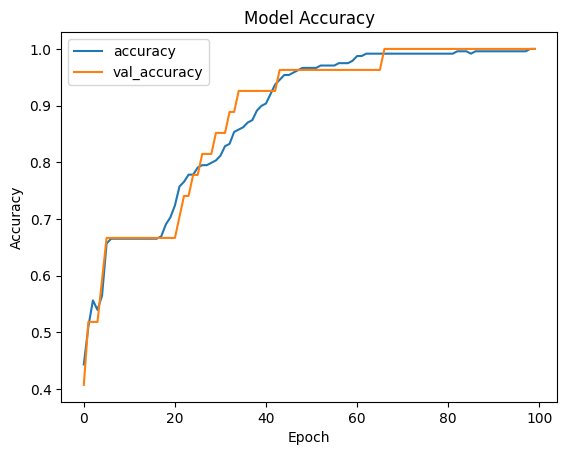

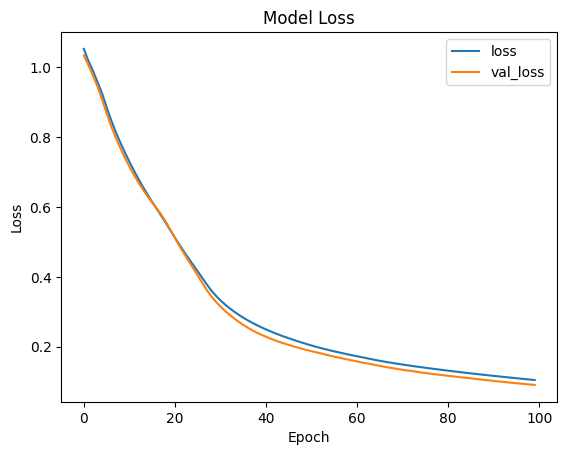

In [12]:
history_df = pd.DataFrame(history.history)

history_df[['accuracy', 'val_accuracy']].plot()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

history_df[['loss', 'val_loss']].plot()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## 13. Evaluate the first model

- Evaluate the trained model on the test data that was not used for fitting.
- Save the loss and accuracy so the result can be compared with another model.

In [13]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose = 0)

print('Test loss:', test_loss)
print('Test accuracy:', test_accuracy)

Test loss: 0.11174504458904266
Test accuracy: 0.9850746393203735


## 14. Make class predictions

- Use model.predict() to get probabilities for each species.
- Convert the highest probability in each row into a predicted species class.

In [14]:
prediction_probabilities = model.predict(x_test)
prediction_codes = np.argmax(prediction_probabilities, axis = 1)

prediction_results = pd.DataFrame({
    'actual_code': y_test,
    'predicted_code': prediction_codes,
    'actual_species': [species_lookup[i] for i in y_test],
    'predicted_species': [species_lookup[i] for i in prediction_codes]
})

prediction_results.head(10)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


,actual_code,predicted_code,actual_species,predicted_species
0,0,0,Adelie,Adelie
1,2,2,Gentoo,Gentoo
2,2,2,Gentoo,Gentoo
3,0,0,Adelie,Adelie
4,0,0,Adelie,Adelie
5,2,2,Gentoo,Gentoo
6,2,2,Gentoo,Gentoo
7,2,2,Gentoo,Gentoo
8,0,0,Adelie,Adelie
9,1,1,Chinstrap,Chinstrap


## 15. Calculate classification metrics

- Create a confusion matrix to compare actual species and predicted species.
- Calculate accuracy, precision, recall, and F1 score for the test data.

In [15]:
print(confusion_matrix(y_test, prediction_codes))
print('Accuracy:', accuracy_score(y_test, prediction_codes))
print('Precision:', precision_score(y_test, prediction_codes, average = 'weighted'))
print('Recall:', recall_score(y_test, prediction_codes, average = 'weighted'))
print('F1 score:', f1_score(y_test, prediction_codes, average = 'weighted'))

[[29  0  0]
 [ 1 13  0]
 [ 0  0 24]]
Accuracy: 0.9850746268656716
Precision: 0.9855721393034825
Recall: 0.9850746268656716
F1 score: 0.9849247172798905


## 16. Build a second model with Adam

- Create a second neural network with the same input and output setup.
- Use Adam as another optimizer because it is a common default choice for Keras models.

In [16]:
# construct a second model
inputs_2 = keras.Input(shape = (x_train.shape[1],))
x_2 = layers.Dense(16, activation = 'relu')(inputs_2)
x_2 = layers.Dense(8, activation = 'relu')(x_2)
x_2 = layers.Dense(4, activation = 'relu')(x_2)
outputs_2 = layers.Dense(3, activation = 'softmax')(x_2)
model_adam = keras.Model(inputs = inputs_2, outputs = outputs_2, name = 'penguin_model_adam')

model_adam.compile(
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),
    metrics = ['accuracy'],
)

history_adam = model_adam.fit(
    x_train,
    y_train,
    batch_size = 32,
    epochs = 100,
    validation_split = 0.1,
    verbose = 0
)

## 17. Compare the two models

- Evaluate both models on the same test data.
- Put the results in one table so the optimizer comparison is easy to read.

In [17]:
rmsprop_loss, rmsprop_accuracy = model.evaluate(x_test, y_test, verbose = 0)
adam_loss, adam_accuracy = model_adam.evaluate(x_test, y_test, verbose = 0)

model_results = pd.DataFrame({
    'model': ['RMSprop model', 'Adam model'],
    'test_loss': [rmsprop_loss, adam_loss],
    'test_accuracy': [rmsprop_accuracy, adam_accuracy]
})

model_results

,model,test_loss,test_accuracy
0,RMSprop model,0.111745,0.985075
1,Adam model,0.324044,0.791045


## 18. Use the final model for predictions

- Choose the model with the higher test accuracy as the final model.
- Show predicted probabilities and species labels for a few test rows.

In [18]:
if adam_accuracy > rmsprop_accuracy:
    final_model = model_adam
    final_model_name = 'Adam model'
else:
    final_model = model
    final_model_name = 'RMSprop model'

final_probabilities = final_model.predict(x_test)
final_codes = np.argmax(final_probabilities, axis = 1)

final_predictions = pd.DataFrame(final_probabilities, columns = [species_lookup[i] for i in range(3)])
final_predictions['predicted_species'] = [species_lookup[i] for i in final_codes]
final_predictions['actual_species'] = [species_lookup[i] for i in y_test]

print(final_model_name)
final_predictions.head(10)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
RMSprop model


,Adelie,Chinstrap,Gentoo,predicted_species,actual_species
0,0.999815,1.720132e-05,1.674918e-04,Adelie,Adelie
1,0.000010,1.948149e-07,9.999894e-01,Gentoo,Gentoo
2,0.001242,4.528430e-06,9.987537e-01,Gentoo,Gentoo
3,1.000000,2.802409e-07,5.684631e-11,Adelie,Adelie
4,0.983703,1.586448e-02,4.329674e-04,Adelie,Adelie
5,0.000006,9.279478e-08,9.999937e-01,Gentoo,Gentoo
6,0.000006,9.138245e-08,9.999937e-01,Gentoo,Gentoo
7,0.000030,6.843336e-07,9.999695e-01,Gentoo,Gentoo
8,1.000000,2.365270e-07,4.447457e-11,Adelie,Adelie
9,0.198425,6.222524e-01,1.793224e-01,Chinstrap,Chinstrap
